In [5]:
# --- Imports and path setup ---------------------------------------------
# Standard scientific Python stack.  scikit-rf is used in section 11 to read
# a touchstone file; not strictly required for the other sections.

from pathlib import Path
import re
from collections import Counter
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skrf as rf

# ---- Paths -------------------------------------------------------------------
# Edit PROJ_ROOT below if your repo is in a different location.
PROJ_ROOT = Path.home() / "mece_project_inverse_model" / "Generative_Inverse_Design_of_High-Speed_Interconnects"
NOTEBOOKS_DIR = PROJ_ROOT / "notebooks"

# Both datasets follow the same layout: <root>/data/raw/<DatasetName>/parameter.csv + variation/
DATA_PATHS = {
    "Array": PROJ_ROOT / "data" / "raw" / "Universal-Diff-SI-Array",
    "Link" : PROJ_ROOT / "data" / "raw" / "Universal-Diff-SI-Link",
}

# Where to drop EDA figures so we can re-use them in the thesis later.
FIG_DIR = NOTEBOOKS_DIR  / "results" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Sanity-check the paths early — fail loud if anything is missing.
for name, p in DATA_PATHS.items():
    csv_path = p / "parameter.csv"
    var_dir  = p / "variation"
    print(f"[{name}]  csv exists: {csv_path.exists()}   variation/ exists: {var_dir.exists()}")


[Array]  csv exists: True   variation/ exists: True
[Link]  csv exists: True   variation/ exists: True


In [6]:
# --- Load both CSVs into a dict of DataFrames --------------------------------
# The Array CSV is documented to have 16 columns; the Link CSV has 18
# (the extras being LENGTH and SL_WIDTH for the MTL trace).
# Both CSVs share a typo in the loss-tangent column ("LOSTANGENT" with one S);
# we rename it to LOSSTANGENT on load for sanity.

dfs = {}
for name, p in DATA_PATHS.items():
    df = pd.read_csv(p / "parameter.csv")
    # Fix the documented typo in the CSV header if present.
    if "LOSTANGENT" in df.columns and "LOSSTANGENT" not in df.columns:
        df = df.rename(columns={"LOSTANGENT": "LOSSTANGENT"})
    dfs[name] = df
    print(f"[{name}]  shape = {df.shape}   columns = {df.shape[1]}")

# Show the columns that each dataset has so we can confirm which one carries
# LENGTH and SL_WIDTH (Link-only, per TUHH docs).
print()
for name, df in dfs.items():
    print(f"[{name}] columns:  {list(df.columns)}")


[Array]  shape = (1916, 16)   columns = 16
[Link]  shape = (1073, 18)   columns = 18

[Array] columns:  ['SIM_ID', 'PERMITTIVITY', 'CONDUCTIVITY', 'LOSSTANGENT', 'TDIEL', 'TMET', 'LAYER_AMOUNT', 'VIAS_X_AMOUNT', 'VIAS_Y_AMOUNT', 'VIA_RADIUS', 'SIMULATION', 'ANTIPAD_RADIUS', 'PITCH', 'SIGNAL_AMOUNT', 'GROUND_AMOUNT', 'POWER_AMOUNT']
[Link] columns:  ['SIM_ID', 'PERMITTIVITY', 'CONDUCTIVITY', 'LOSSTANGENT', 'TDIEL', 'TMET', 'LAYER_AMOUNT', 'VIAS_X_AMOUNT', 'VIAS_Y_AMOUNT', 'VIA_RADIUS', 'LENGTH', 'SL_WIDTH', 'SIMULATION', 'ANTIPAD_RADIUS', 'PITCH', 'SIGNAL_AMOUNT', 'GROUND_AMOUNT', 'POWER_AMOUNT']


In [7]:
# --- Schema and integrity check ----------------------------------------------

for name, df in dfs.items():
    print(f"========== [{name}] ==========")

    # 2a. dtype summary
    non_numeric = df.dtypes[df.dtypes == "object"].index.tolist()
    print(f"  non-numeric columns:   {non_numeric}   (expected: ['SIMULATION'])")

    # 2b. null check
    nulls = df.isna().sum()
    if nulls.any():
        print("  NULL VALUES FOUND:")
        print(nulls[nulls > 0])
    else:
        print("  null values:          none")

    # 2c. duplicates on SIM_ID
    dup_ids = df["SIM_ID"].duplicated().sum()
    print(f"  duplicate SIM_IDs:    {dup_ids}")

    # 2d. simulation-folder coverage: does every CSV row correspond to a folder
    #     under variation/, and does every folder correspond to a CSV row?
    var_dir = DATA_PATHS[name] / "variation"
    csv_sims = set(df["SIMULATION"].astype(str))
    fs_sims = {p.name for p in var_dir.iterdir() if p.is_dir()}

    missing_on_disk = csv_sims - fs_sims          # in CSV but no folder
    missing_in_csv  = fs_sims  - csv_sims          # folder but no CSV row
    print(f"  simulations in CSV:   {len(csv_sims)}")
    print(f"  folders on disk:      {len(fs_sims)}")
    print(f"  in CSV, no folder:    {len(missing_on_disk)}")
    print(f"  on disk, no CSV row:  {len(missing_in_csv)}")
    if missing_on_disk:
        print(f"    examples: {list(missing_on_disk)[:5]}")
    if missing_in_csv:
        print(f"    examples: {list(missing_in_csv)[:5]}")
    print()


========== [Array] ==========
  non-numeric columns:   []   (expected: ['SIMULATION'])
  null values:          none
  duplicate SIM_IDs:    0
  simulations in CSV:   1916
  folders on disk:      1916
  in CSV, no folder:    0
  on disk, no CSV row:  0

========== [Link] ==========
  non-numeric columns:   []   (expected: ['SIMULATION'])
  null values:          none
  duplicate SIM_IDs:    0
  simulations in CSV:   1073
  folders on disk:      1073
  in CSV, no folder:    0
  on disk, no CSV row:  0



========== [Array] geometric features ==========


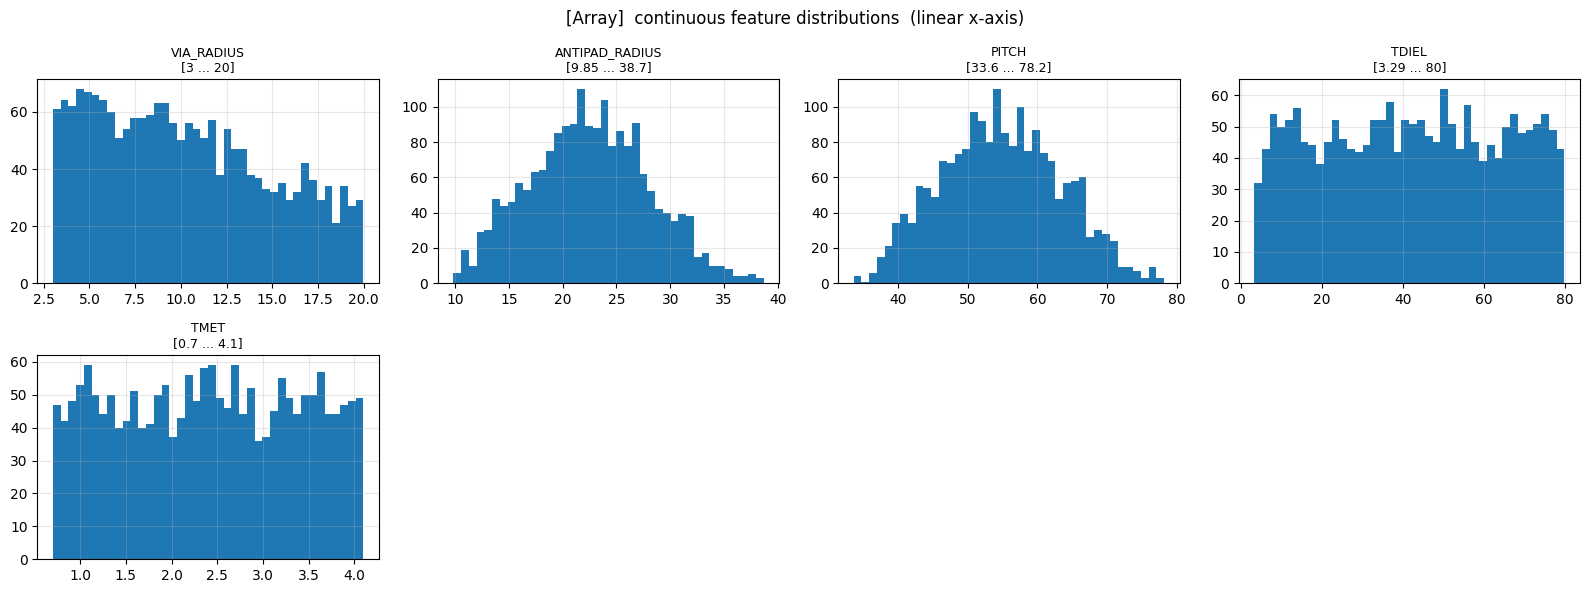

========== [Array] material features  (linear) ==========


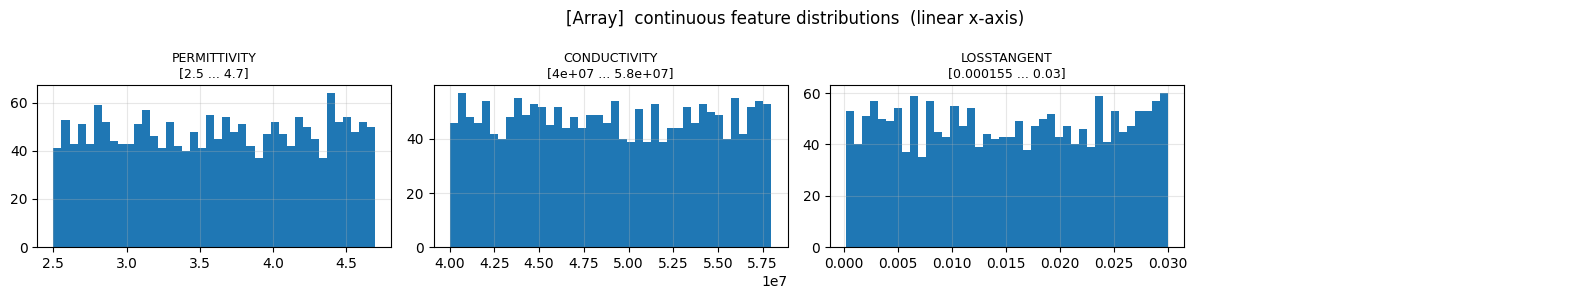

========== [Array] material features  (log)    ==========


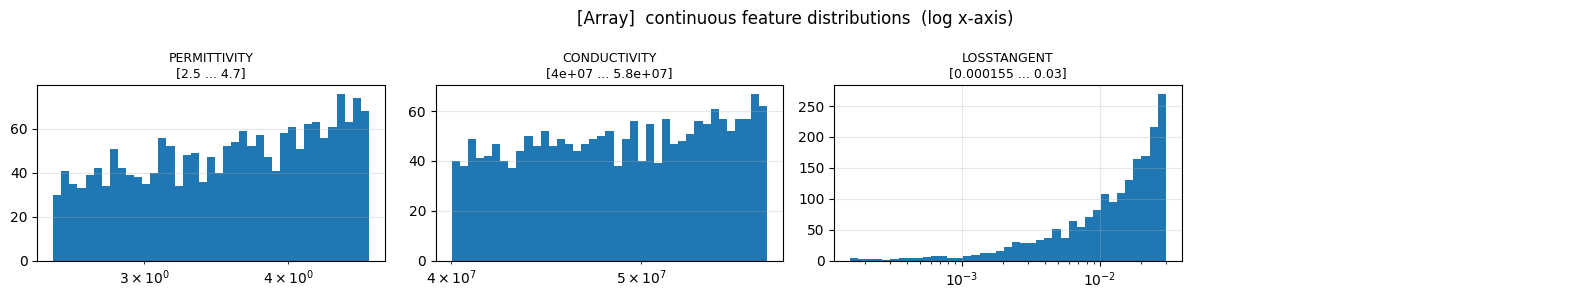

========== [Link] geometric features ==========


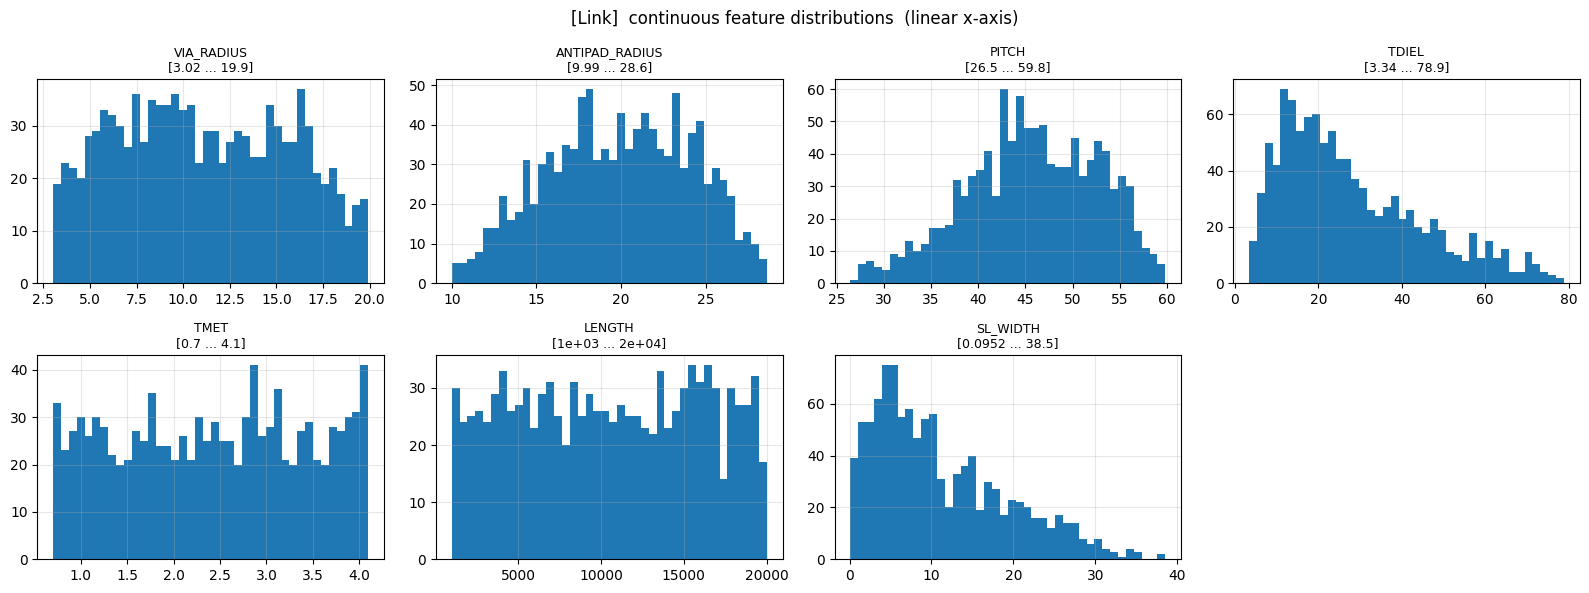

========== [Link] material features  (linear) ==========


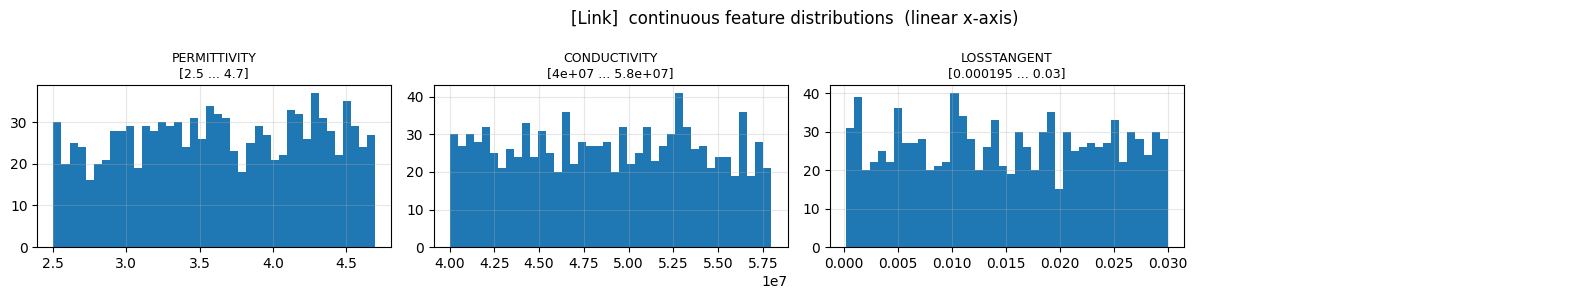

========== [Link] material features  (log)    ==========


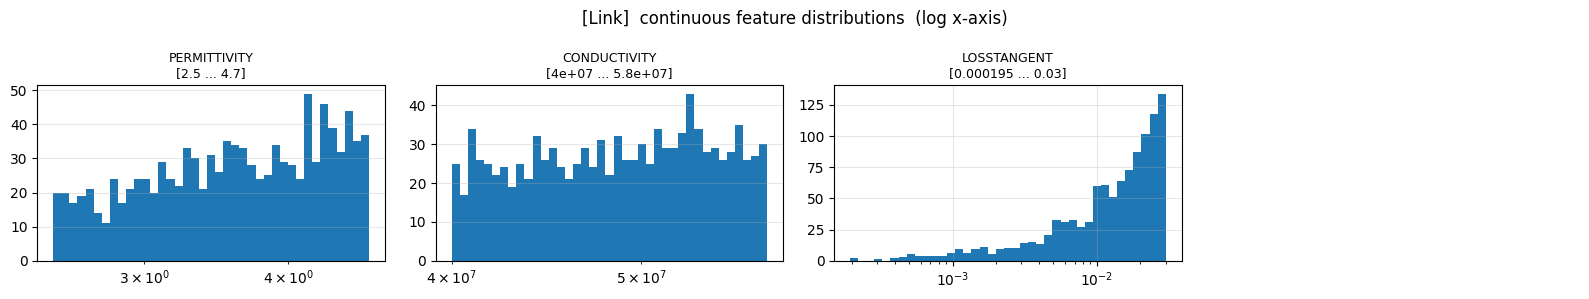

In [8]:
# --- Histograms of continuous features ---------------------------------------

CONTINUOUS_GEOM = ["VIA_RADIUS", "ANTIPAD_RADIUS", "PITCH",
                   "TDIEL", "TMET", "LENGTH", "SL_WIDTH"]
CONTINUOUS_MAT  = ["PERMITTIVITY", "CONDUCTIVITY", "LOSSTANGENT"]

def hist_grid(df, columns, name, log_x=False):
    """Plot a grid of histograms, skipping columns that don't exist."""
    cols_present = [c for c in columns if c in df.columns]
    if not cols_present:
        return
    n = len(cols_present)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, col in zip(axes, cols_present):
        x = df[col].values
        if log_x:
            # Use log-spaced bins; clip non-positive values defensively.
            x_pos = x[x > 0]
            ax.hist(x_pos, bins=np.logspace(np.log10(x_pos.min()),
                                            np.log10(x_pos.max()), 40))
            ax.set_xscale("log")
        else:
            ax.hist(x, bins=40)
        ax.set_title(f"{col}\n[{x.min():.3g} ... {x.max():.3g}]", fontsize=9)
        ax.grid(alpha=0.3)
    # Hide unused subplots
    for ax in axes[len(cols_present):]:
        ax.axis("off")
    fig.suptitle(f"[{name}]  continuous feature distributions"
                 + ("  (log x-axis)" if log_x else "  (linear x-axis)"),
                 fontsize=12)
    fig.tight_layout()
    return fig

for name, df in dfs.items():
    print(f"========== [{name}] geometric features ==========")
    fig = hist_grid(df, CONTINUOUS_GEOM, name, log_x=False)
    if fig is not None:
        fig.savefig(FIG_DIR / f"{name}_geom_hist.png", dpi=120, bbox_inches="tight")
    plt.show()

    print(f"========== [{name}] material features  (linear) ==========")
    fig = hist_grid(df, CONTINUOUS_MAT,  name, log_x=False)
    if fig is not None:
        fig.savefig(FIG_DIR / f"{name}_mat_lin_hist.png", dpi=120, bbox_inches="tight")
    plt.show()

    print(f"========== [{name}] material features  (log)    ==========")
    fig = hist_grid(df, CONTINUOUS_MAT,  name, log_x=True)
    if fig is not None:
        fig.savefig(FIG_DIR / f"{name}_mat_log_hist.png", dpi=120, bbox_inches="tight")
    plt.show()


========== [Array] discrete topology features ==========


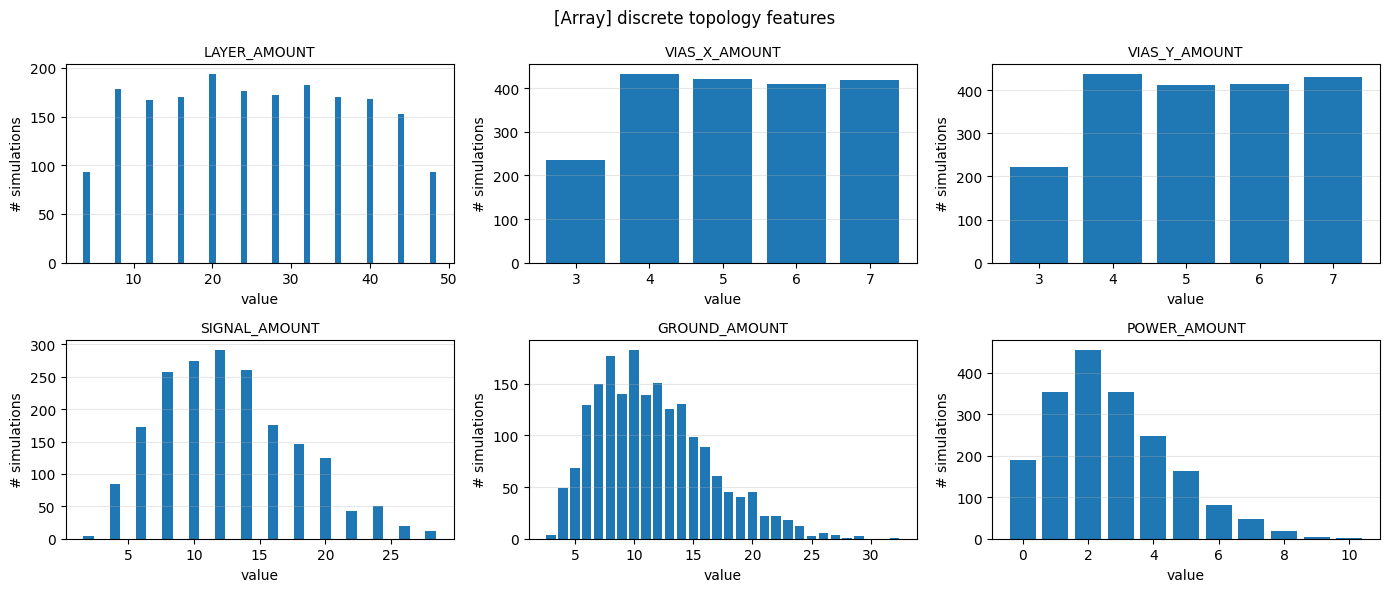

  LAYER_AMOUNT        min=   4   max=  48
  VIAS_X_AMOUNT       min=   3   max=   7
  VIAS_Y_AMOUNT       min=   3   max=   7
  SIGNAL_AMOUNT       min=   2   max=  28
  GROUND_AMOUNT       min=   3   max=  32
  POWER_AMOUNT        min=   0   max=  10

========== [Link] discrete topology features ==========


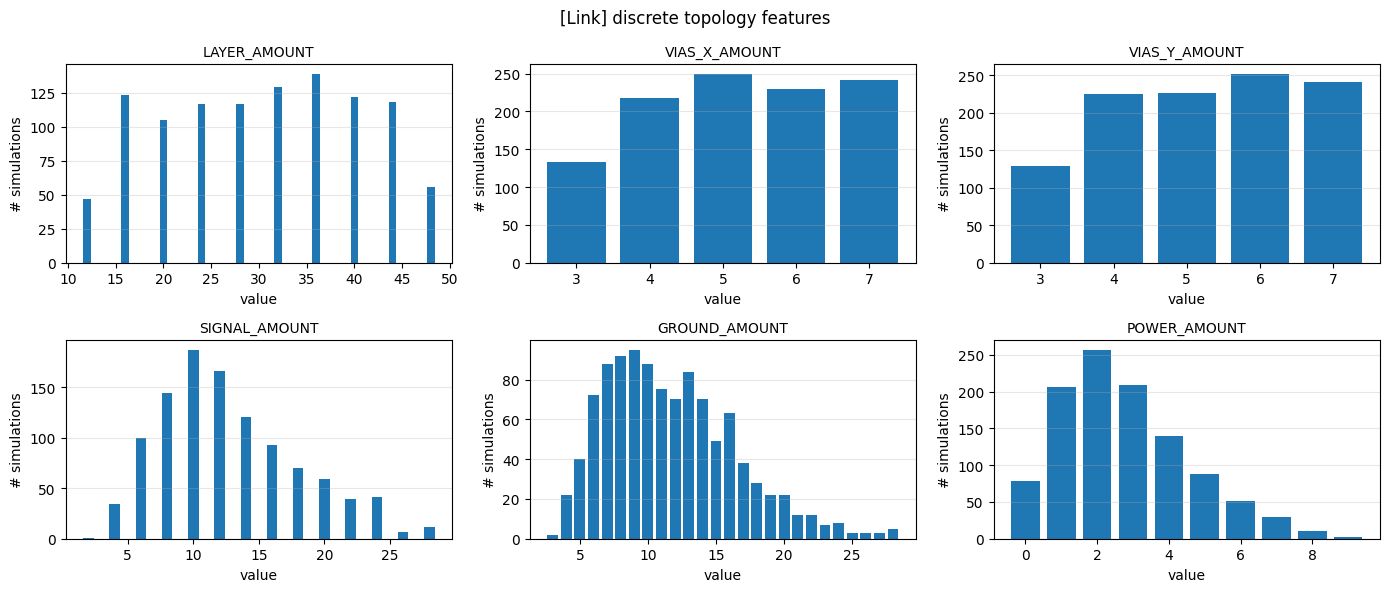

  LAYER_AMOUNT        min=  12   max=  48
  VIAS_X_AMOUNT       min=   3   max=   7
  VIAS_Y_AMOUNT       min=   3   max=   7
  SIGNAL_AMOUNT       min=   2   max=  28
  GROUND_AMOUNT       min=   3   max=  28
  POWER_AMOUNT        min=   0   max=   9



In [9]:
# --- Distributions of discrete topology features -----------------------------

DISCRETE = ["LAYER_AMOUNT", "VIAS_X_AMOUNT", "VIAS_Y_AMOUNT",
            "SIGNAL_AMOUNT", "GROUND_AMOUNT", "POWER_AMOUNT"]

for name, df in dfs.items():
    print(f"========== [{name}] discrete topology features ==========")
    fig, axes = plt.subplots(2, 3, figsize=(14, 6))
    for ax, col in zip(axes.flatten(), DISCRETE):
        if col not in df.columns:
            ax.axis("off"); continue
        vals, counts = np.unique(df[col].values, return_counts=True)
        ax.bar(vals.astype(int), counts, width=0.8)
        ax.set_title(f"{col}", fontsize=10)
        ax.set_xlabel("value"); ax.set_ylabel("# simulations")
        ax.grid(alpha=0.3, axis="y")
    fig.suptitle(f"[{name}] discrete topology features", fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}_discrete_hist.png", dpi=120, bbox_inches="tight")
    plt.show()

    # Also print min/max for quick reference
    for col in DISCRETE:
        if col in df.columns:
            print(f"  {col:18s}  min={df[col].min():>4.0f}   max={df[col].max():>4.0f}")
    print()


========== [Array] geometric feasibility ==========
  antipad > via_radius:     min margin = 6.009 mil   violations = 0
  pitch > 2*antipad:        min margin = 0.001 mil     violations = 0


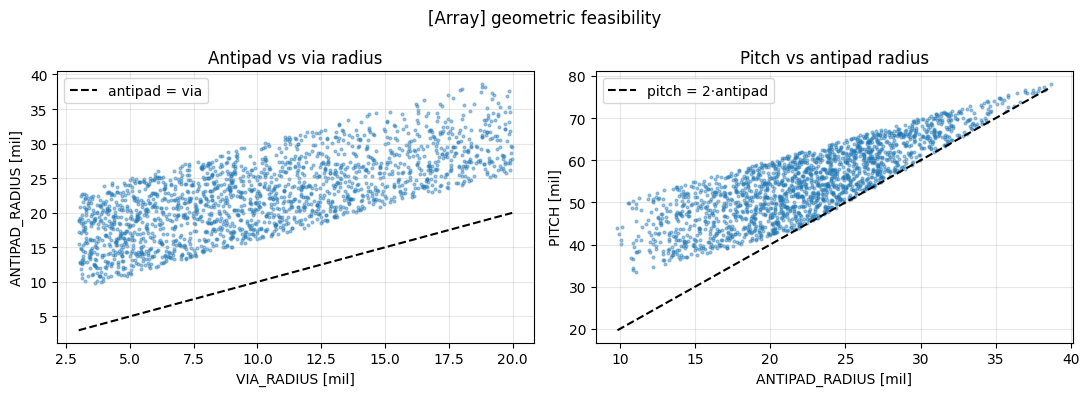


========== [Link] geometric feasibility ==========
  antipad > via_radius:     min margin = 6.000 mil   violations = 0
  pitch > 2*antipad:        min margin = 0.006 mil     violations = 0


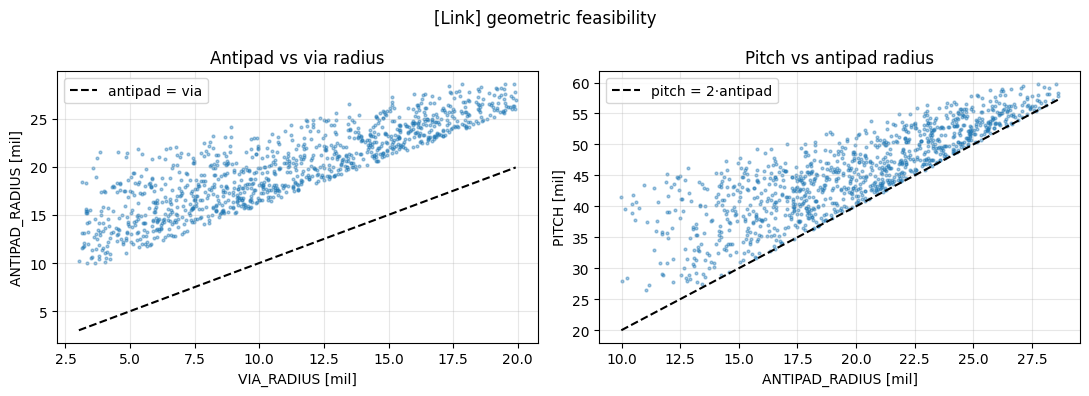

In [10]:
# --- Geometric feasibility audit ---------------------------------------------

for name, df in dfs.items():
    print(f"========== [{name}] geometric feasibility ==========")

    # Compute the two safety margins explicitly so we can plot them.
    margin_antipad = df["ANTIPAD_RADIUS"] - df["VIA_RADIUS"]
    margin_pitch   = df["PITCH"] - 2 * df["ANTIPAD_RADIUS"]

    n_violations_antipad = (margin_antipad <= 0).sum()
    n_violations_pitch   = (margin_pitch   <= 0).sum()

    print(f"  antipad > via_radius:     "
          f"min margin = {margin_antipad.min():.3f} mil   violations = {n_violations_antipad}")
    print(f"  pitch > 2*antipad:        "
          f"min margin = {margin_pitch.min():.3f} mil     violations = {n_violations_pitch}")

    # Plot the joint distribution so we can see how close to the constraint surface
    # the LHS sampler is operating.
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(df["VIA_RADIUS"], df["ANTIPAD_RADIUS"], s=4, alpha=0.4)
    rmin, rmax = df["VIA_RADIUS"].min(), df["VIA_RADIUS"].max()
    axes[0].plot([rmin, rmax], [rmin, rmax], "k--", label="antipad = via")
    axes[0].set_xlabel("VIA_RADIUS [mil]")
    axes[0].set_ylabel("ANTIPAD_RADIUS [mil]")
    axes[0].set_title("Antipad vs via radius")
    axes[0].grid(alpha=0.3); axes[0].legend()

    axes[1].scatter(df["ANTIPAD_RADIUS"], df["PITCH"], s=4, alpha=0.4)
    amin, amax = df["ANTIPAD_RADIUS"].min(), df["ANTIPAD_RADIUS"].max()
    axes[1].plot([amin, amax], [2*amin, 2*amax], "k--", label="pitch = 2·antipad")
    axes[1].set_xlabel("ANTIPAD_RADIUS [mil]")
    axes[1].set_ylabel("PITCH [mil]")
    axes[1].set_title("Pitch vs antipad radius")
    axes[1].grid(alpha=0.3); axes[1].legend()

    fig.suptitle(f"[{name}] geometric feasibility", fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}_geom_feasibility.png", dpi=120, bbox_inches="tight")
    plt.show()
    print()


In [11]:
# --- Connectivity audit ------------------------------------------------------

for name, df in dfs.items():
    n_via_slots = df["VIAS_X_AMOUNT"] * df["VIAS_Y_AMOUNT"]
    n_via_used  = df["SIGNAL_AMOUNT"] + df["GROUND_AMOUNT"] + df["POWER_AMOUNT"]
    delta = n_via_slots - n_via_used

    n_violations = (delta != 0).sum()
    print(f"[{name}]  rows where  X*Y  !=  S+G+P :  {n_violations}")
    if n_violations:
        bad = df.loc[delta != 0, ["SIM_ID", "SIMULATION",
                                  "VIAS_X_AMOUNT", "VIAS_Y_AMOUNT",
                                  "SIGNAL_AMOUNT", "GROUND_AMOUNT", "POWER_AMOUNT"]]
        print("  first 5 violations:")
        print(bad.head().to_string(index=False))
    else:
        print("  All rows consistent with X*Y == S+G+P  (good).")
    print()


[Array]  rows where  X*Y  !=  S+G+P :  0
  All rows consistent with X*Y == S+G+P  (good).

[Link]  rows where  X*Y  !=  S+G+P :  0
  All rows consistent with X*Y == S+G+P  (good).



In [12]:
# --- Port-count distribution and consistency check --------------------------

PORT_RE = re.compile(r"\.s(\d+)p$")    # matches .s12p, .s52p, etc.

def discover_touchstones(variation_dir):
    """Yield (sim_id, num_ports, filepath) for every touchstone file found."""
    for sim_dir in variation_dir.iterdir():
        if not sim_dir.is_dir():
            continue
        for f in sim_dir.iterdir():
            m = PORT_RE.search(f.name)
            if m:
                yield sim_dir.name, int(m.group(1)), f
                break        # one touchstone per simulation

port_results = {}
for name, p in DATA_PATHS.items():
    print(f"========== [{name}] scanning touchstone files ==========")
    df = dfs[name]
    rows = list(discover_touchstones(p / "variation"))
    print(f"  found {len(rows)} touchstone files")
    counts = Counter(n for _, n, _ in rows)
    for k in sorted(counts):
        print(f"    {k:>3d} ports : {counts[k]:>4d} simulations")
    port_results[name] = pd.DataFrame(rows, columns=["SIMULATION", "NUM_PORTS", "filepath"])
    port_results[name]["filepath"] = port_results[name]["filepath"].astype(str)

    # Cross-check the documented rule:  N = 2 * SIGNAL_AMOUNT
    merged = df.merge(port_results[name][["SIMULATION", "NUM_PORTS"]], on="SIMULATION", how="left")
    expected = 2 * merged["SIGNAL_AMOUNT"]
    bad = merged["NUM_PORTS"] != expected
    print(f"  N_ports == 2 * SIGNAL_AMOUNT  ?   "
          f"violations = {bad.sum()} / {len(merged)}")
    if bad.any():
        print("    first 5 violations:")
        print(merged.loc[bad, ["SIMULATION", "SIGNAL_AMOUNT", "NUM_PORTS"]].head().to_string(index=False))
    print()


========== [Array] scanning touchstone files ==========
  found 1916 touchstone files
      4 ports :    4 simulations
      8 ports :   84 simulations
     12 ports :  173 simulations
     16 ports :  258 simulations
     20 ports :  274 simulations
     24 ports :  292 simulations
     28 ports :  260 simulations
     32 ports :  175 simulations
     36 ports :  146 simulations
     40 ports :  125 simulations
     44 ports :   43 simulations
     48 ports :   50 simulations
     52 ports :   20 simulations
     56 ports :   12 simulations
  N_ports == 2 * SIGNAL_AMOUNT  ?   violations = 0 / 1916

========== [Link] scanning touchstone files ==========
  found 1073 touchstone files
      4 ports :    1 simulations
      8 ports :   34 simulations
     12 ports :  100 simulations
     16 ports :  144 simulations
     20 ports :  187 simulations
     24 ports :  166 simulations
     28 ports :  120 simulations
     32 ports :   93 simulations
     40 ports :   70 simulations
     48 por

Dataset   #sims    current   augmented   mult
--------------------------------------------------
Array      1916       1916       12130  6.33x
Link       1073       1073        7436  6.93x


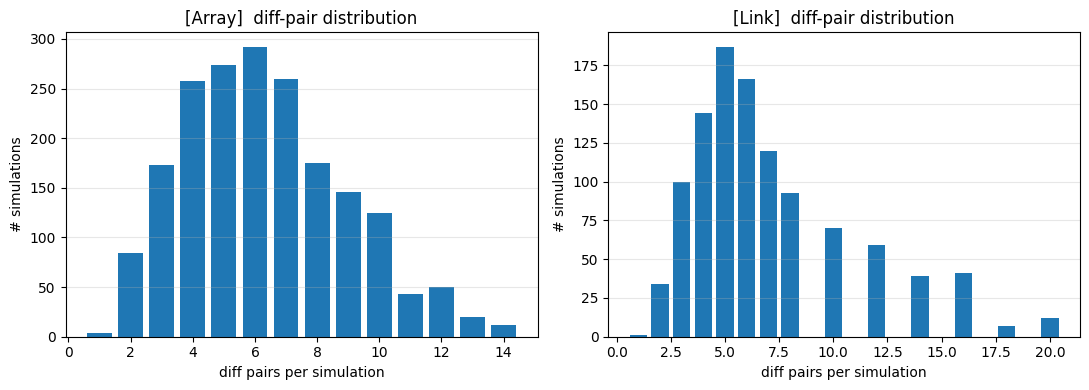

In [13]:
# --- Diff-pair augmentation summary ------------------------------------------

print(f"{'Dataset':<8} {'#sims':>6} {'current':>10} {'augmented':>11} {'mult':>6}")
print("-" * 50)
augment_table = {}
for name in DATA_PATHS:
    df = dfs[name].merge(port_results[name][["SIMULATION", "NUM_PORTS"]], on="SIMULATION", how="left")
    df["NUM_DIFF_PAIRS"] = df["NUM_PORTS"] // 4
    current   = len(df)
    augmented = int(df["NUM_DIFF_PAIRS"].sum())
    mult      = augmented / current if current else float("nan")
    augment_table[name] = (current, augmented, mult)
    print(f"{name:<8} {current:>6d} {current:>10d} {augmented:>11d} {mult:>5.2f}x")

# Also visualise the diff-pairs-per-sim distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, DATA_PATHS):
    df = dfs[name].merge(port_results[name][["SIMULATION", "NUM_PORTS"]], on="SIMULATION", how="left")
    df["NUM_DIFF_PAIRS"] = df["NUM_PORTS"] // 4
    vals, counts = np.unique(df["NUM_DIFF_PAIRS"], return_counts=True)
    ax.bar(vals, counts)
    ax.set_xlabel("diff pairs per simulation")
    ax.set_ylabel("# simulations")
    ax.set_title(f"[{name}]  diff-pair distribution")
    ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(FIG_DIR / "diff_pairs_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


In [14]:
# --- Parser helpers (will be moved into data/parse_via_array.py) ------------

ARRAY_VIA_LINE = re.compile(
    r"^arr_(?P<arr>\d+)_via_(?P<x>\d+)_(?P<y>\d+)_sgn(?P<sgn>\d+)(?:_link(?P<link>\d+))?_?(?P<half>pup|plw)?\s*$"
)
# Port-name patterns we expect:
#   arr_1_via_4_4_sgn1pup      (Array, has top/bottom halves)
#   arr_1_via_4_4_sgn1plw
#   arr_1_via_4_2_sgn1_link1_pup   (Link, back-drilled, single port per via)


def parse_via_array(path):
    """Parse a via_array.txt file. Returns dict with vias, array_grid, layers."""
    text = Path(path).read_text()

    # ---- 1. Stackup section (we just count layers here; full parse in section 10)
    layer_list_match = re.search(r"layer list: \[(.*?)\]", text)
    layers = []
    if layer_list_match:
        layers = [s.strip().strip("'\"") for s in layer_list_match.group(1).split(",")]

    # ---- 2. Port lines (one per port, in order)
    port_lines = []
    for line in text.splitlines():
        m = ARRAY_VIA_LINE.match(line.strip())
        if m:
            port_lines.append({
                "port_idx_1based": len(port_lines) + 1,
                "arr":  int(m.group("arr")),
                "x":    int(m.group("x")),
                "y":    int(m.group("y")),
                "sgn":  int(m.group("sgn")),
                "link": int(m.group("link")) if m.group("link") else None,
                "half": m.group("half"),       # 'pup', 'plw', or None
            })

    # ---- 3. [ARRAY] grid section
    grid = []
    in_grid = False
    for line in text.splitlines():
        if line.strip().startswith("[ARRAY]"):
            in_grid = True; continue
        if in_grid:
            row = line.strip()
            if not row: break
            # tokens like "G17", "S3", "P2"
            tokens = re.findall(r"[GSP]\d+", row)
            if tokens:
                grid.append(tokens)
    return {"layers": layers, "ports": port_lines, "grid": grid}


def describe_via_array(name, sim_id):
    """Pretty-print the parsed via_array for one simulation."""
    path = DATA_PATHS[name] / "variation" / sim_id / "via_array.txt"
    if not path.exists():
        print(f"  via_array.txt not found at {path}")
        return None
    parsed = parse_via_array(path)

    print(f"  layers: {len(parsed['layers'])}   first few: {parsed['layers'][:8]}")
    print(f"  ports:  {len(parsed['ports'])}")
    if parsed["ports"]:
        print(f"    first port:  {parsed['ports'][0]}")
        print(f"    second port: {parsed['ports'][1]}")
        print(f"    last port:   {parsed['ports'][-1]}")

    # 2-D grid
    grid = parsed["grid"]
    if grid:
        print(f"  grid shape: {len(grid)} rows x {len(grid[0])} cols")
        for row in grid:
            print("    " + "  ".join(f"{t:>3s}" for t in row))

    # Identify diff pairs:  pairs of consecutive sgn numbers (sgn1+sgn2, sgn3+sgn4, ...)
    sgns = sorted({p["sgn"] for p in parsed["ports"]})
    n_diff_pairs = len(sgns) // 2
    print(f"  unique signal IDs found: {len(sgns)}  ->  diff pairs: {n_diff_pairs}")
    return parsed


# Try one example from each dataset
EXAMPLE_SIMS = {
    "Array": None,    # auto-pick a mid-port-count sample below
    "Link" : None,
}
for name in DATA_PATHS:
    # pick the first simulation with at least 8 ports for a clean example
    df = port_results[name]
    eligible = df[df["NUM_PORTS"] >= 8].sort_values("NUM_PORTS")
    if len(eligible):
        EXAMPLE_SIMS[name] = eligible.iloc[len(eligible) // 2]["SIMULATION"]

for name, sim in EXAMPLE_SIMS.items():
    print(f"========== [{name}]  {sim} ==========")
    describe_via_array(name, sim)
    print()


========== [Array]  sim_pkg_7520 ==========
  layers: 0   first few: []
  ports:  24
    first port:  {'port_idx_1based': 1, 'arr': 1, 'x': 4, 'y': 3, 'sgn': 1, 'link': None, 'half': 'pup'}
    second port: {'port_idx_1based': 2, 'arr': 1, 'x': 4, 'y': 3, 'sgn': 1, 'link': None, 'half': 'plw'}
    last port:   {'port_idx_1based': 24, 'arr': 1, 'x': 2, 'y': 1, 'sgn': 12, 'link': None, 'half': 'plw'}
  grid shape: 4 rows x 6 cols
     G8   S3   S9   P3   S7   G9
     G6   S4  S10   S1   S8   G7
     S5  S11   G3   S2   G4   G5
     S6  S12   P1   G1   P2   G2
  unique signal IDs found: 12  ->  diff pairs: 6

========== [Link]  sim_pkg_1922 ==========
  layers: 0   first few: []
  ports:  24
    first port:  {'port_idx_1based': 1, 'arr': 1, 'x': 4, 'y': 3, 'sgn': 1, 'link': 1, 'half': 'pup'}
    second port: {'port_idx_1based': 2, 'arr': 1, 'x': 4, 'y': 2, 'sgn': 2, 'link': 1, 'half': 'pup'}
    last port:   {'port_idx_1based': 24, 'arr': 2, 'x': 6, 'y': 3, 'sgn': 12, 'link': 6, 'half': '

In [15]:
# --- stackup.txt parsing -----------------------------------------------------
# stackup.txt usually contains the same layer list found inside via_array.txt
# (or a dedicated layer ordering); we just count and tabulate the layer types.

def parse_stackup(path):
    text = Path(path).read_text()
    # Try the same regex as via_array.txt
    layer_list_match = re.search(r"layer list: \[(.*?)\]", text)
    layers = []
    if layer_list_match:
        layers = [s.strip().strip("'\"") for s in layer_list_match.group(1).split(",")]
    return layers

for name, sim in EXAMPLE_SIMS.items():
    path = DATA_PATHS[name] / "variation" / sim / "stackup.txt"
    print(f"========== [{name}]  {sim}  stackup.txt ==========")
    if not path.exists():
        print("  not found; if missing for all sims, use via_array.txt's layer list instead\n")
        continue

    layers = parse_stackup(path)
    counts = Counter(layers)
    print(f"  total layers parsed: {len(layers)}")
    for k, v in sorted(counts.items()):
        print(f"    {k:>5s} : {v}")

    csv_layer = int(dfs[name].set_index("SIMULATION").loc[sim, "LAYER_AMOUNT"])
    plane_or_signal = sum(1 for x in layers if x in ("G", "S", "P"))
    print(f"  conducting layers (G+S+P): {plane_or_signal}   parameter.csv LAYER_AMOUNT: {csv_layer}")
    print()


========== [Array]  sim_pkg_7520  stackup.txt ==========
  total layers parsed: 63
      D/2 : 31
        G : 16
        P : 2
        S : 14
  conducting layers (G+S+P): 32   parameter.csv LAYER_AMOUNT: 32

========== [Link]  sim_pkg_1922  stackup.txt ==========
  total layers parsed: 63
      D/2 : 31
        G : 16
        P : 2
        S : 14
  conducting layers (G+S+P): 32   parameter.csv LAYER_AMOUNT: 32



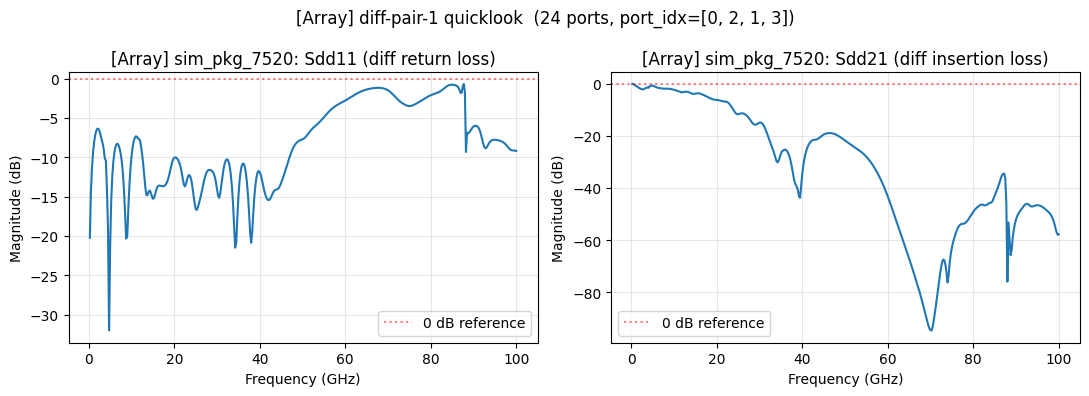

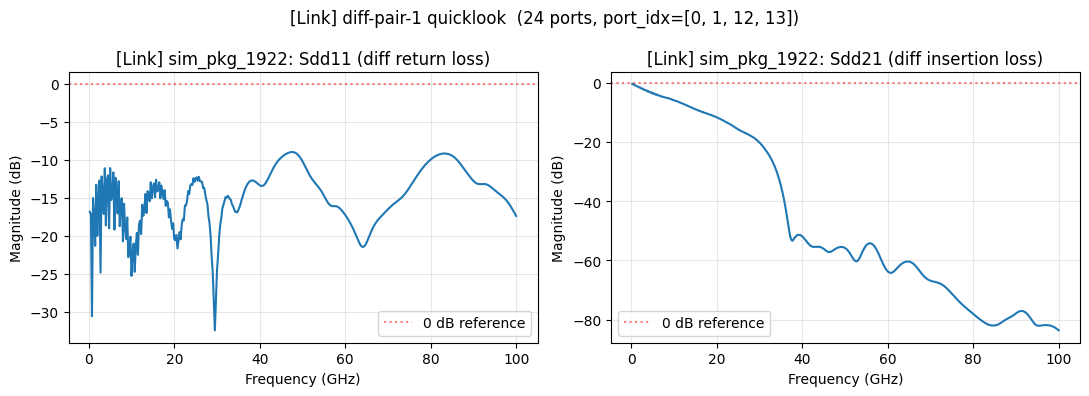

In [18]:
# --- Quick S-parameter visualisation (CORRECTED for Array vs Link) -----------
# This cell now picks the right port-extraction per dataset.
#
# Array: ports are interleaved per via -> diff pair 1 = sgn1+sgn2
#        ports (1-indexed) = (1, 2, 3, 4) -> (0-indexed) (0, 1, 2, 3)
#        B-E ordering [TX+, TX-, RX+, RX-] = (sgn1pup, sgn2pup, sgn1plw, sgn2plw)
#        -> indices [0, 2, 1, 3]
#
# Link: ports are grouped by array -> diff pair 1 = link1 (arr1_sgn1+arr1_sgn2 paired with arr2_sgn1+arr2_sgn2)
#        ports (1-indexed) = (1, 2, half+1, half+2)
#        B-E ordering = (arr1_sgn1, arr1_sgn2, arr2_sgn1, arr2_sgn2)
#        -> indices [0, 1, half, half+1]

def first_diff_pair_indices(dataset_name: str, num_ports: int) -> list[int]:
    """Return the four 0-indexed port positions for diff pair 1 in B-E order."""
    half = num_ports // 2
    if dataset_name == "Array":
        # Pair 1 sits in ports 0..3 of an interleaved layout.
        return [0, 2, 1, 3]
    elif dataset_name == "Link":
        # Pair 1 is split across two arrays grouped contiguously.
        return [0, 1, half, half + 1]
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")


def plot_first_diff_pair(name, sim):
    """Plot Sdd11 and Sdd21 for diff pair 1, with correct port extraction."""
    path = DATA_PATHS[name] / "variation" / sim
    ts = next(path.glob("*.s*p"), None)
    if ts is None:
        print(f"  no touchstone in {path}"); return

    ntwk = rf.Network(str(ts))
    port_idx = first_diff_pair_indices(name, ntwk.number_of_ports)
    s_se = ntwk.s[:, port_idx][:, :, port_idx]      # (F, 4, 4) single-ended
    f_GHz = ntwk.f / 1e9

    # Bockelman-Eisenstadt: [TX+, TX-, RX+, RX-] -> [d_TX, d_RX, c_TX, c_RX]
    M = (1 / np.sqrt(2)) * np.array([[ 1, -1,  0,  0],
                                     [ 0,  0,  1, -1],
                                     [ 1,  1,  0,  0],
                                     [ 0,  0,  1,  1]])
    s_mm = M @ s_se @ M.T

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(f_GHz, 20 * np.log10(np.abs(s_mm[:, 0, 0]) + 1e-12))
    axes[0].set_title(f"[{name}] {sim}: Sdd11 (diff return loss)")
    axes[0].set_xlabel("Frequency (GHz)"); axes[0].set_ylabel("Magnitude (dB)")
    axes[0].grid(alpha=0.3)
    axes[0].axhline(0, color="r", linestyle=":", alpha=0.5, label="0 dB reference")
    axes[0].legend()

    axes[1].plot(f_GHz, 20 * np.log10(np.abs(s_mm[:, 1, 0]) + 1e-12))
    axes[1].set_title(f"[{name}] {sim}: Sdd21 (diff insertion loss)")
    axes[1].set_xlabel("Frequency (GHz)"); axes[1].set_ylabel("Magnitude (dB)")
    axes[1].grid(alpha=0.3)
    axes[1].axhline(0, color="r", linestyle=":", alpha=0.5, label="0 dB reference")
    axes[1].legend()

    fig.suptitle(f"[{name}] diff-pair-1 quicklook  ({ntwk.number_of_ports} ports, "
                 f"port_idx={port_idx})", fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}_quicklook_{sim}.png", dpi=120, bbox_inches="tight")
    plt.show()


for name, sim in EXAMPLE_SIMS.items():
    if sim:
        plot_first_diff_pair(name, sim)

In [17]:
# --- Final EDA summary -------------------------------------------------------

print("=" * 72)
print("                     EDA SUMMARY")
print("=" * 72)
for name, df in dfs.items():
    n_sims = len(df)
    n_cols = df.shape[1]
    nulls  = df.isna().sum().sum()
    has_length    = "LENGTH"    in df.columns
    has_sl_width  = "SL_WIDTH"  in df.columns
    layer_range   = (int(df["LAYER_AMOUNT"].min()), int(df["LAYER_AMOUNT"].max()))
    sig_range     = (int(df["SIGNAL_AMOUNT"].min()), int(df["SIGNAL_AMOUNT"].max()))

    pr = port_results[name]
    aug = augment_table[name]

    print(f"\n[{name}]")
    print(f"  simulations:                   {n_sims}")
    print(f"  feature columns:               {n_cols}")
    print(f"  null values:                   {nulls}")
    print(f"  has LENGTH column:             {has_length}")
    print(f"  has SL_WIDTH column:           {has_sl_width}")
    print(f"  LAYER_AMOUNT range:            {layer_range[0]} ... {layer_range[1]}")
    print(f"  SIGNAL_AMOUNT range:           {sig_range[0]} ... {sig_range[1]}")
    print(f"  port-count range:              {pr['NUM_PORTS'].min()} ... {pr['NUM_PORTS'].max()}")
    print(f"  ----- diff-pair augmentation -----")
    print(f"    current dataset size:        {aug[0]}")
    print(f"    after augmentation:          {aug[1]}")
    print(f"    multiplier:                  {aug[2]:.2f}x")

print()
print("Figures saved to:", FIG_DIR)
print("=" * 72)


                     EDA SUMMARY

[Array]
  simulations:                   1916
  feature columns:               16
  null values:                   0
  has LENGTH column:             False
  has SL_WIDTH column:           False
  LAYER_AMOUNT range:            4 ... 48
  SIGNAL_AMOUNT range:           2 ... 28
  port-count range:              4 ... 56
  ----- diff-pair augmentation -----
    current dataset size:        1916
    after augmentation:          12130
    multiplier:                  6.33x

[Link]
  simulations:                   1073
  feature columns:               18
  null values:                   0
  has LENGTH column:             True
  has SL_WIDTH column:           True
  LAYER_AMOUNT range:            12 ... 48
  SIGNAL_AMOUNT range:           2 ... 28
  port-count range:              4 ... 80
  ----- diff-pair augmentation -----
    current dataset size:        1073
    after augmentation:          7436
    multiplier:                  6.93x

Figures saved to: /